In [1]:
%run setup.py

import ydf
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import LeaveOneGroupOut
import matplotlib.pyplot as plt
from collections import defaultdict

pandas_ds = pd.read_csv("../data/DogFeatures.csv")


In [2]:
def lodo_validation(dataset, learner):
    logo = LeaveOneGroupOut()
    group = dataset["DogID"]
    X = dataset.drop(columns=["DogID", "label"])
    y = dataset["label"]

    accuracies = []
    f1_scores = []
    matrices = []

    classes = sorted(dataset["label"].unique())

    for train_ix, test_ix in logo.split(X, y, groups=group):
        train_df = dataset.iloc[train_ix]
        test_df = dataset.iloc[test_ix]

        test_subject = test_df["DogID"].iloc[0]

        train_df = train_df.drop(columns=["DogID"])
        test_df = test_df.drop(columns=["DogID"])

        model = learner.train(train_df, verbose=0)

        probs = model.predict(test_df)
        preds = np.argmax(probs, axis=1)

        model_classes = model.label_classes()
        preds_labels = np.array([model_classes[int(i)] for i in preds])

        y_true = test_df["label"].values

        acc = accuracy_score(y_true, preds_labels)
        f1_weighted = f1_score(y_true, preds_labels, average="weighted")
        f1_macro = f1_score(y_true, preds_labels, average="macro")

        accuracies.append(acc)
        f1_scores.append((f1_weighted, f1_macro))

        cm = confusion_matrix(y_true, preds_labels, labels=classes)
        matrices.append(cm)

    return accuracies, f1_scores, matrices, classes

In [3]:
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

def lodo_validation_sampling(dataset, learner, sampling=None, random_state=42):
    logo = LeaveOneGroupOut()
    group = dataset["DogID"]
    X = dataset.drop(columns=["DogID", "label"])
    y = dataset["label"]

    accuracies = []
    f1_scores = []
    matrices = []

    classes = sorted(dataset["label"].unique())

    for train_ix, test_ix in logo.split(X, y, groups=group):
        train_df = dataset.iloc[train_ix].copy()
        test_df = dataset.iloc[test_ix].copy()

        X_train = train_df.drop(columns=["DogID", "label"]) 
        y_train = train_df["label"]

        if sampling == 'undersample':
            rus = RandomUnderSampler(random_state=random_state)
            X_res, y_res = rus.fit_resample(X_train, y_train)
        elif sampling == 'oversample':
            ros = RandomOverSampler(random_state=random_state)
            X_res, y_res = ros.fit_resample(X_train, y_train)
        elif sampling == 'smote':
            sm = SMOTE(random_state=random_state)
            X_res, y_res = sm.fit_resample(X_train, y_train)
        else:
            raise ValueError(f"Unsupported sampling method: {sampling}")

        X_res = pd.DataFrame(X_res, columns=X_train.columns)
        train_resampled = X_res.copy()
        train_resampled['label'] = y_res

        model = learner.train(train_resampled, verbose=0)

        test_for_pred = test_df.drop(columns=["DogID"]) if "DogID" in test_df.columns else test_df

        probs = model.predict(test_for_pred)
        preds = np.argmax(probs, axis=1)

        model_classes = model.label_classes()
        preds_labels = np.array([model_classes[int(i)] for i in preds])

        y_true = test_df["label"].values

        acc = accuracy_score(y_true, preds_labels)
        f1_weighted = f1_score(y_true, preds_labels, average="weighted")
        f1_macro = f1_score(y_true, preds_labels, average="macro")

        accuracies.append(acc)
        f1_scores.append((f1_weighted, f1_macro))

        cm = confusion_matrix(y_true, preds_labels, labels=classes)
        matrices.append(cm)

    return accuracies, f1_scores, matrices, classes


In [14]:
def show_metrics(accuracies, f1_scores, matrices, classes):
    print("Accuracy:", np.mean(accuracies))
    print("F1 Score (weighted):", np.mean([f[0] for f in f1_scores]))
    print("F1 Score (macro):", np.mean([f[1] for f in f1_scores]))

    global_matrix = np.sum(matrices, axis=0)

    disp = ConfusionMatrixDisplay(confusion_matrix=global_matrix, display_labels=classes)
    disp.plot(xticks_rotation=45)
    plt.show()

Features mais importantes

In [7]:
used_features = [
    "label", "DogID", "ABack_z_std", "GBack_z_std", "GBack_z_abs_sum", "ANeck_y_mean", "GBack_x_std",
    "GBack_y_std", "ABack_y_median", "ANeck_y_median", "ABack_y_max", "ABack_y_mean",
    "ABack_y_std", "GBack_x_min", "ABack_z_min", "ABack_y_min", "ANeck_y_min",
    "ANeck_y_max", "GBack_x_abs_sum", "GBack_y_abs_sum", "ABack_x_std",
    "ABack_y_abs_sum", "ABack_z_mean", "GBack_x_mean", "ABack_z_median",
    "GBack_x_median", "ABack_z_max", "GBack_y_min", "GBack_x_max", "GBack_y_max",
    "GBack_z_max", "Age months", "GBack_z_min", "ABack_z_abs_sum", "ANeck_y_std",
    "ABack_x_min", "ANeck_x_std", "ANeck_z_min", "ANeck_y_abs_sum", "ABack_x_mean",
    "ABack_x_abs_sum", "Weight", "ABack_x_max", "ABack_x_median", "ANeck_z_std",
    "ANeck_x_min", "ANeck_z_abs_sum", "GBack_z_mean", "ANeck_z_max", "ANeck_x_mean",
    "ANeck_x_max", "GBack_y_median"
]

ds_filtred = pandas_ds[used_features]

### Sem balanceamento

##### Sem pesos nas classes

Accuracy: 0.8539998288471234
F1 Score (weighted): 0.8473553866105823
F1 Score (macro): 0.7881510322438577


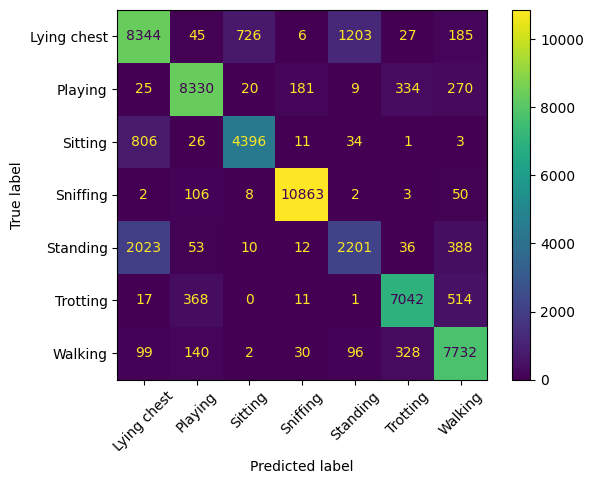

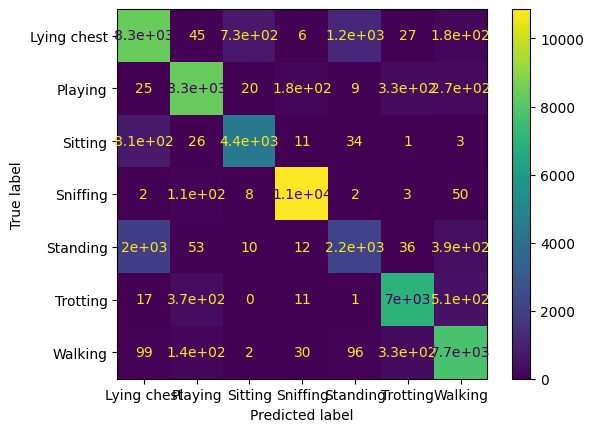

In [9]:
simple_learner = ydf.RandomForestLearner(
    label = "label",
    task = ydf.Task.CLASSIFICATION,
    num_trees = 100
)

acc, f1, matrices, classes = lodo_validation(ds_filtred, simple_learner)

show_metrics(acc, f1, matrices, classes)

##### Com pesos nas classes

In [12]:
unique_classes, count = np.unique(ds_filtred["label"], return_counts=True)
total_sample = len(ds_filtred)
n_classes = len(unique_classes)

weights = {}
for cls, cnt in zip(unique_classes, count):
    weight = total_sample / (n_classes * cnt)
    weights[cls] = weight

Accuracy: 0.8532037880557372
F1 Score (weighted): 0.8484707519091763
F1 Score (macro): 0.7902523382988758


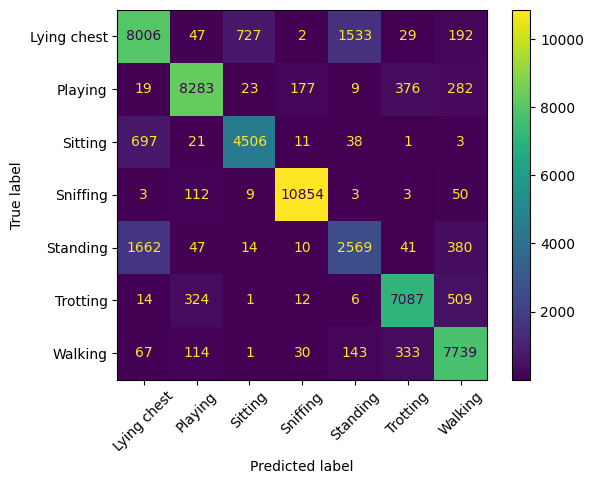

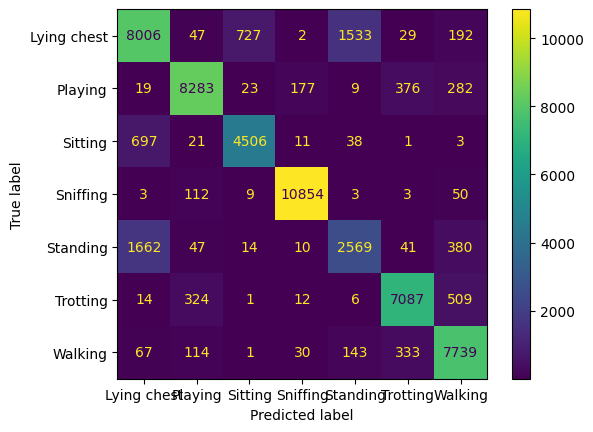

In [13]:
weight_learner = ydf.RandomForestLearner(
    label = "label",
    task = ydf.Task.CLASSIFICATION,
    num_trees = 100,
    class_weights = weights
)

acc, f1, matrices, classes = lodo_validation(ds_filtred, weight_learner)

show_metrics(acc, f1, matrices, classes)

### Com balanceamento artificial

Undersampling


Accuracy: 0.852130440631541
F1 Score (weighted): 0.8491420215270336
F1 Score (macro): 0.7910816813762427


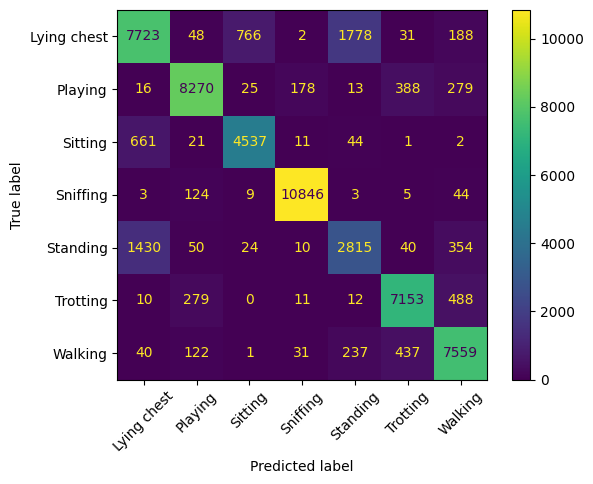

In [15]:
under_learner = ydf.RandomForestLearner(
    label = "label",
    task = ydf.Task.CLASSIFICATION,
    num_trees = 100
)

acc, f1, matrices, classes = lodo_validation_sampling(ds_filtred, under_learner, sampling='undersample')

show_metrics(acc, f1, matrices, classes)

Oversampling

Accuracy: 0.8525376534821645
F1 Score (weighted): 0.8474361036368809
F1 Score (macro): 0.7893112079973774


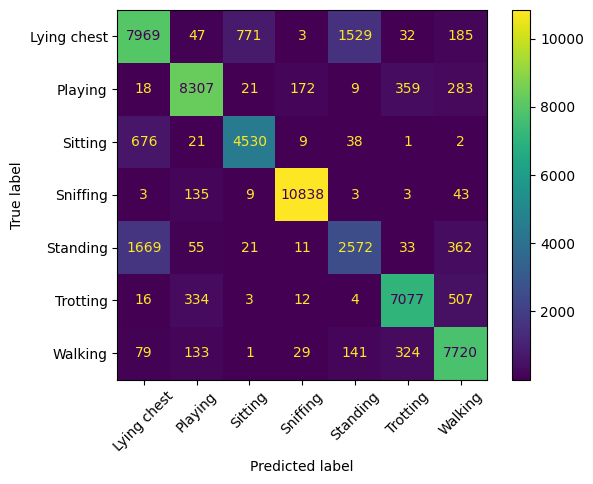

In [16]:
over_learner = ydf.RandomForestLearner(
    label = "label",
    task = ydf.Task.CLASSIFICATION,
    num_trees = 100
)

acc, f1, matrices, classes = lodo_validation_sampling(ds_filtred, over_learner, sampling='oversample')
show_metrics(acc, f1, matrices, classes)

SMOTE

Accuracy: 0.8481241658824102
F1 Score (weighted): 0.8437602142131385
F1 Score (macro): 0.786795521802692


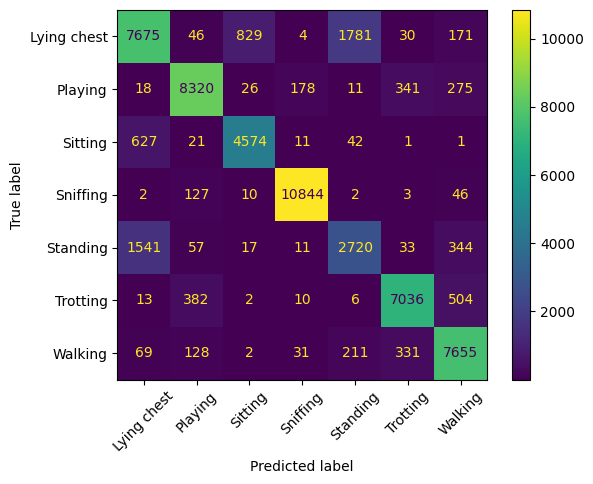

In [17]:
smote_learner = ydf.RandomForestLearner(
    label="label",
    task= ydf.Task.CLASSIFICATION,
    num_trees=100
)

acc, f1, matrices, classes = lodo_validation_sampling(ds_filtred, smote_learner, "smote")

show_metrics(acc, f1, matrices, classes)